In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#4.2 Ethical aspects and EDI check

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)


In [3]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Coursework 2/retail_store_sales.csv")

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False



Columns detected for removal: ['Customer ID', 'Transaction ID']

Column Comparison Table:


,Columns Before,Columns After
0,Transaction ID,Category
1,Customer ID,Item
2,Category,Price Per Unit
3,Item,Quantity
4,Price Per Unit,Total Spent
5,Quantity,Payment Method
6,Total Spent,Location
7,Payment Method,Transaction Date
8,Location,Discount Applied
9,Transaction Date,NaN


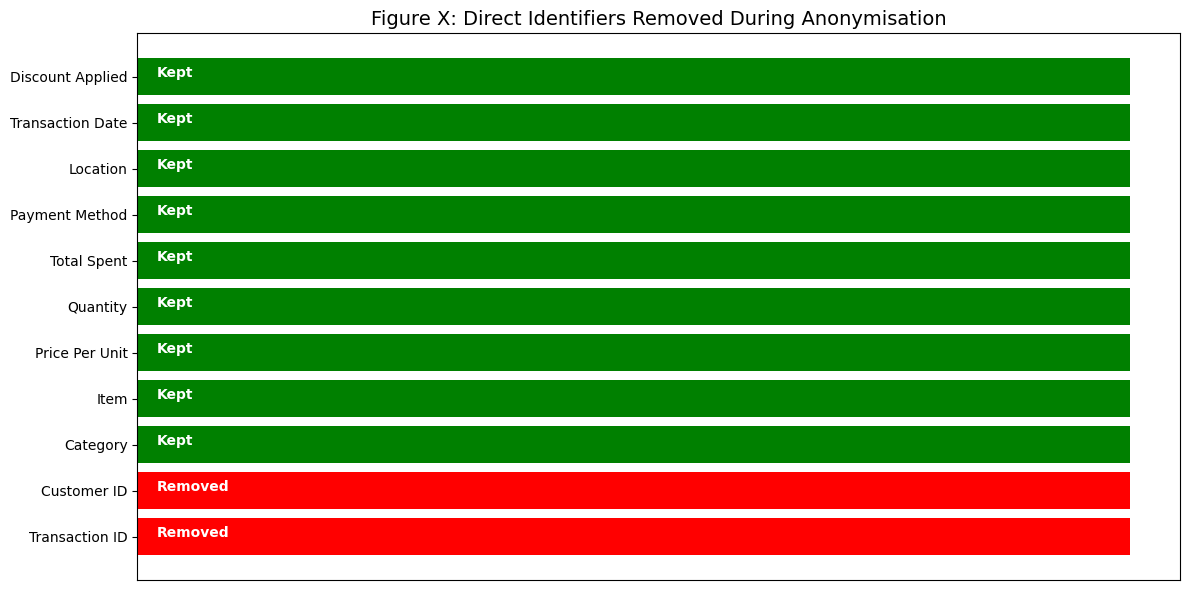

In [4]:

display(df.head())

# Remove ONLY the exact direct identifiers
direct_to_drop = ['Customer ID', 'Transaction ID']

# Keep only columns that actually exist to prevent KeyError
valid_drop = [c for c in direct_to_drop if c in df.columns]

print("\nColumns detected for removal:", valid_drop)

# Drop them safely
df_anon = df.drop(columns=valid_drop)

# Comparison Table
comparison = pd.DataFrame({
    "Columns Before": pd.Series(df.columns),
    "Columns After": pd.Series(df_anon.columns)
})

print("\nColumn Comparison Table:")
display(comparison)

# Visualisation
cols = df.columns
status = ["Removed" if c in valid_drop else "Kept" for c in cols]

plt.figure(figsize=(12, 6))
plt.barh(cols, [1]*len(cols),
         color=["red" if s == "Removed" else "green" for s in status])
plt.title("Figure X: Direct Identifiers Removed During Anonymisation", fontsize=14)
plt.xticks([])

for i, s in enumerate(status):
    plt.text(0.02, i, s, color="white", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()



Column: 'Category'
Number of categories before: 8
Rare values (< 5%): None
Number of categories after:  8

Top categories before vs after collapsing:


,Before,After
Category,,
Electric household essentials,0.127,0.127
Furniture,0.127,0.127
Food,0.126,0.126
Milk Products,0.126,0.126
Butchers,0.125,0.125
Beverages,0.125,0.125
Computers and electric accessories,0.124,0.124
Patisserie,0.122,0.122


<Figure size 1000x500 with 0 Axes>

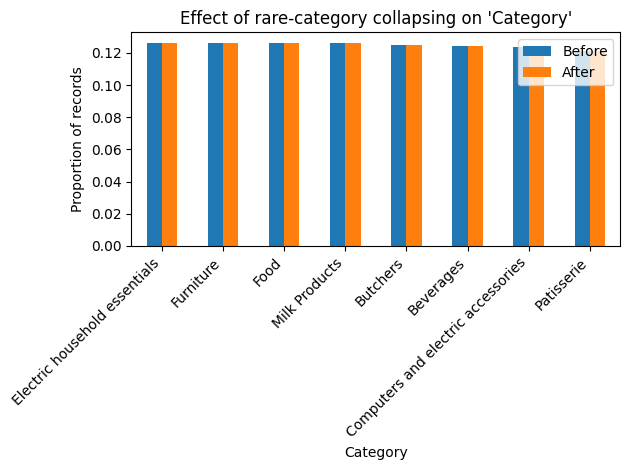


Column: 'Item'
Number of categories before: 201
Rare values (< 5%): ['Item_2_BEV', 'Item_25_FUR', 'Item_11_FUR', 'Item_16_MILK', 'Item_1_MILK', 'Item_5_FUR', 'Item_20_BUT', 'Item_14_FOOD', 'Item_11_MILK', 'Item_19_CEA', 'Item_8_EHE', 'Item_19_MILK', 'Item_24_FUR', 'Item_13_FOOD', 'Item_12_CEA', 'Item_22_BUT', 'Item_14_BEV', 'Item_12_PAT', 'Item_5_CEA', 'Item_25_EHE', 'Item_15_EHE', 'Item_13_MILK', 'Item_25_BUT', 'Item_23_BUT', 'Item_12_BEV', 'Item_5_FOOD', 'Item_6_FUR', 'Item_2_FUR', 'Item_11_PAT', 'Item_3_MILK', 'Item_15_FUR', 'Item_20_FOOD', 'Item_8_FUR', 'Item_17_PAT', 'Item_12_BUT', 'Item_6_MILK', 'Item_23_EHE', 'Item_12_FOOD', 'Item_25_FOOD', 'Item_20_EHE', 'Item_23_PAT', 'Item_17_FOOD', 'Item_20_PAT', 'Item_7_MILK', 'Item_20_FUR', 'Item_17_BEV', 'Item_20_BEV', 'Item_13_BUT', 'Item_8_BEV', 'Item_13_EHE', 'Item_17_EHE', 'Item_23_MILK', 'Item_16_BUT', 'Item_8_MILK', 'Item_25_BEV', 'Item_8_PAT', 'Item_15_BUT', 'Item_20_CEA', 'Item_11_FOOD', 'Item_16_BEV', 'Item_17_MILK', 'Item_15_CE

,Before,After
Item,,
NaN,0.096,0.096
Item_2_BEV,0.010,0.000
Item_25_FUR,0.009,0.000
Item_11_FUR,0.009,0.000
Item_1_MILK,0.009,0.000
Item_16_MILK,0.009,0.000
Item_20_BUT,0.009,0.000
Item_5_FUR,0.009,0.000
Item_11_MILK,0.008,0.000


<Figure size 1000x500 with 0 Axes>

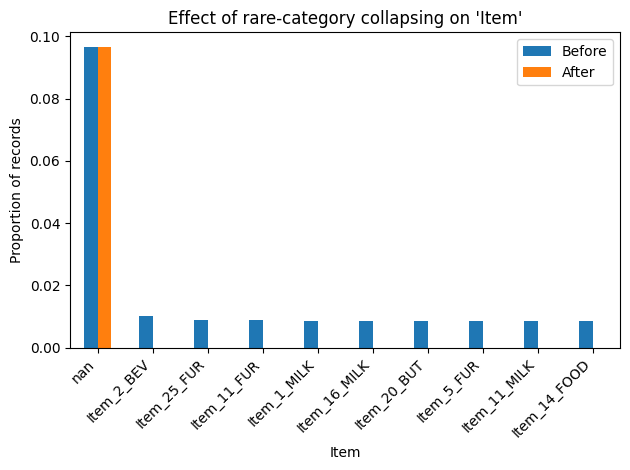


Column: 'Payment Method'
Number of categories before: 3
Rare values (< 5%): None
Number of categories after:  3

Top categories before vs after collapsing:


,Before,After
Payment Method,,
Cash,0.343,0.343
Digital Wallet,0.330,0.330
Credit Card,0.328,0.328


<Figure size 1000x500 with 0 Axes>

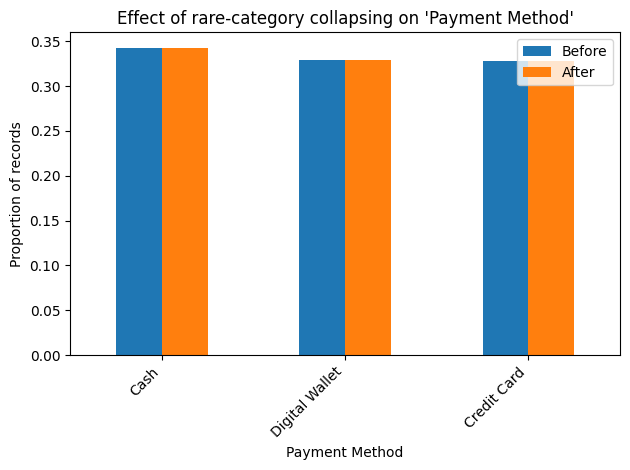


Column: 'Location'
Number of categories before: 2
Rare values (< 5%): None
Number of categories after:  2

Top categories before vs after collapsing:


,Before,After
Location,,
Online,0.505,0.505
In-store,0.495,0.495


<Figure size 1000x500 with 0 Axes>

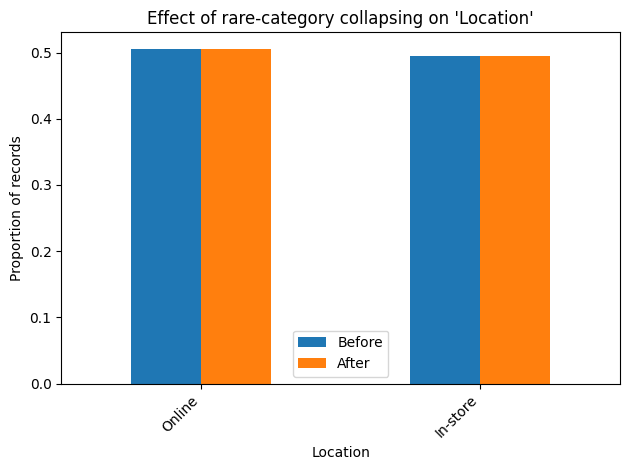


Column: 'Transaction Date'
Number of categories before: 1114
Rare values (< 5%): ['2022-05-30', '2023-07-17', '2024-03-16', '2023-06-12', '2022-01-23', '2022-04-14', '2024-09-29', '2023-06-14', '2023-12-25', '2023-06-10', '2024-08-08', '2023-06-22', '2022-03-02', '2025-01-08', '2023-12-12', '2023-12-31', '2024-12-07', '2024-04-09', '2023-02-24', '2022-07-21', '2024-03-07', '2022-02-02', '2023-05-18', '2023-02-18', '2024-06-11', '2023-06-20', '2022-07-12', '2022-05-22', '2025-01-03', '2023-01-31', '2022-01-13', '2023-12-21', '2023-03-20', '2023-01-18', '2024-01-12', '2022-01-21', '2022-02-14', '2022-08-24', '2023-09-19', '2024-01-03', '2022-04-22', '2023-04-01', '2022-03-01', '2024-02-25', '2022-06-13', '2024-03-10', '2023-08-01', '2024-01-01', '2024-05-08', '2022-07-02', '2024-09-30', '2022-02-18', '2022-08-13', '2022-11-20', '2022-09-09', '2022-01-14', '2023-05-26', '2022-04-05', '2024-07-27', '2024-06-05', '2022-03-31', '2022-01-26', '2023-01-03', '2023-07-13', '2024-01-02', '2023-0

,Before,After
Transaction Date,,
2022-05-30,0.002,0.0
2023-07-17,0.002,0.0
2023-06-12,0.002,0.0
2024-03-16,0.002,0.0
2023-06-14,0.002,0.0
2022-01-23,0.002,0.0
2024-09-29,0.002,0.0
2022-04-14,0.002,0.0
2023-12-25,0.002,0.0


<Figure size 1000x500 with 0 Axes>

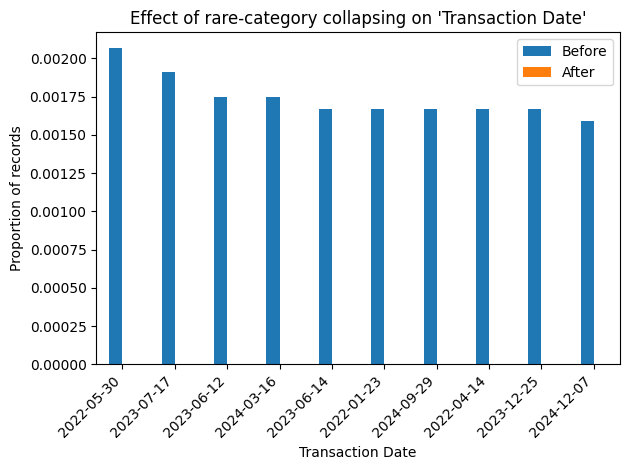


Column: 'Discount Applied'
Number of categories before: 3
Rare values (< 5%): None
Number of categories after:  3

Top categories before vs after collapsing:


,Before,After
Discount Applied,,
True,0.336,0.336
NaN,0.334,0.334
False,0.331,0.331


<Figure size 1000x500 with 0 Axes>

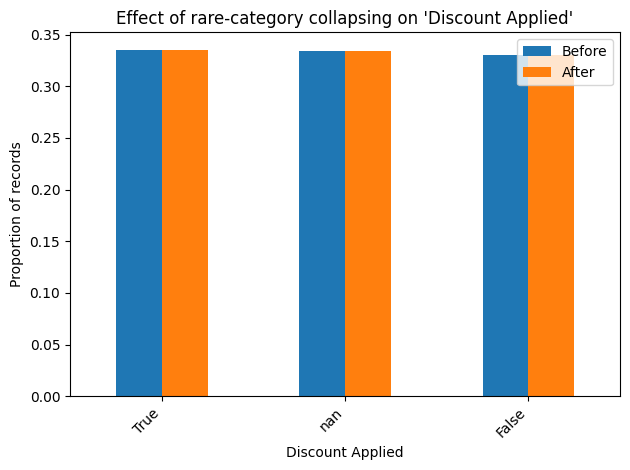

In [5]:
# Collapse rare categorical values WITH VISUALISATION

# Find categorical columns
categorical_cols = [c for c in df_anon.columns if df_anon[c].dtype == 'object']
RARE_THRESHOLD = 0.05  # 5%

for c in categorical_cols:
    print("\n" + "="*70)
    print(f"Column: '{c}'")

    # frequencies BEFORE collapsing
    freqs_before = df_anon[c].value_counts(normalize=True, dropna=False)

    # identify rare values (< 5% of rows)
    rare_vals = [v for v in freqs_before[freqs_before < RARE_THRESHOLD].index if pd.notna(v)]

    print(f"Number of categories before: {freqs_before.shape[0]}")
    print(f"Rare values (< {RARE_THRESHOLD*100:.0f}%): {rare_vals if rare_vals else 'None'}")

    # apply collapsing
    df_anon[c] = df_anon[c].where(~df_anon[c].isin(rare_vals), other='Other')

    # frequencies AFTER collapsing
    freqs_after = df_anon[c].value_counts(normalize=True, dropna=False)

    print(f"Number of categories after:  {freqs_after.shape[0]}")

    # build a comparison table for top categories
    compare_df = pd.DataFrame({
        "Before": freqs_before,
        "After": freqs_after
    }).fillna(0)

    # Sort by 'Before' proportion and keep top 10 for readability
    compare_top = compare_df.sort_values("Before", ascending=False).head(10)

    print("\nTop categories before vs after collapsing:")
    display(compare_top.round(3))

    # visualisation: bar plot before vs after
    plt.figure(figsize=(10, 5))
    compare_top.plot(kind='bar')
    plt.title(f"Effect of rare-category collapsing on '{c}'")
    plt.ylabel("Proportion of records")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


In [6]:
# 3) Coarsen date columns
date_cols = [c for c in df_anon.columns if 'date' in c.lower()]
for c in date_cols:
    parsed = pd.to_datetime(df_anon[c], errors='coerce')
    df_anon[c + "_month"] = parsed.dt.to_period("M").astype(str)
    df_anon[c + "_year"] = parsed.dt.year
    df_anon.drop(columns=c, inplace=True)

In [7]:
#derive age groups if DOB exists
dob_cols = [c for c in df_anon.columns if 'dob' in c.lower()]
for c in dob_cols:
    dob_series = pd.to_datetime(df_anon[c], errors='coerce')
    ages = (pd.to_datetime("2025-11-20") - dob_series).dt.days // 365
    bins = [0,18,30,45,60,200]
    labels = ['0-17','18-29','30-44','45-59','60+']
    df_anon['age_group'] = pd.cut(ages, bins=bins, labels=labels, right=False)
    df_anon.drop(columns=c, inplace=True)

In [8]:
# 5) Check class balance / subgroup distribution
for c in categorical_cols:
    if c in df_anon.columns:
        print(f"\nDistribution for '{c}':")
        print(df_anon[c].value_counts(normalize=True).round(2))


Distribution for 'Category':
Category
Electric household essentials         0.13
Furniture                             0.13
Food                                  0.13
Milk Products                         0.13
Butchers                              0.12
Beverages                             0.12
Computers and electric accessories    0.12
Patisserie                            0.12
Name: proportion, dtype: float64

Distribution for 'Item':
Item
Other    1.0
Name: proportion, dtype: float64

Distribution for 'Payment Method':
Payment Method
Cash              0.34
Digital Wallet    0.33
Credit Card       0.33
Name: proportion, dtype: float64

Distribution for 'Location':
Location
Online      0.51
In-store    0.49
Name: proportion, dtype: float64

Distribution for 'Discount Applied':
Discount Applied
True     0.5
False    0.5
Name: proportion, dtype: float64


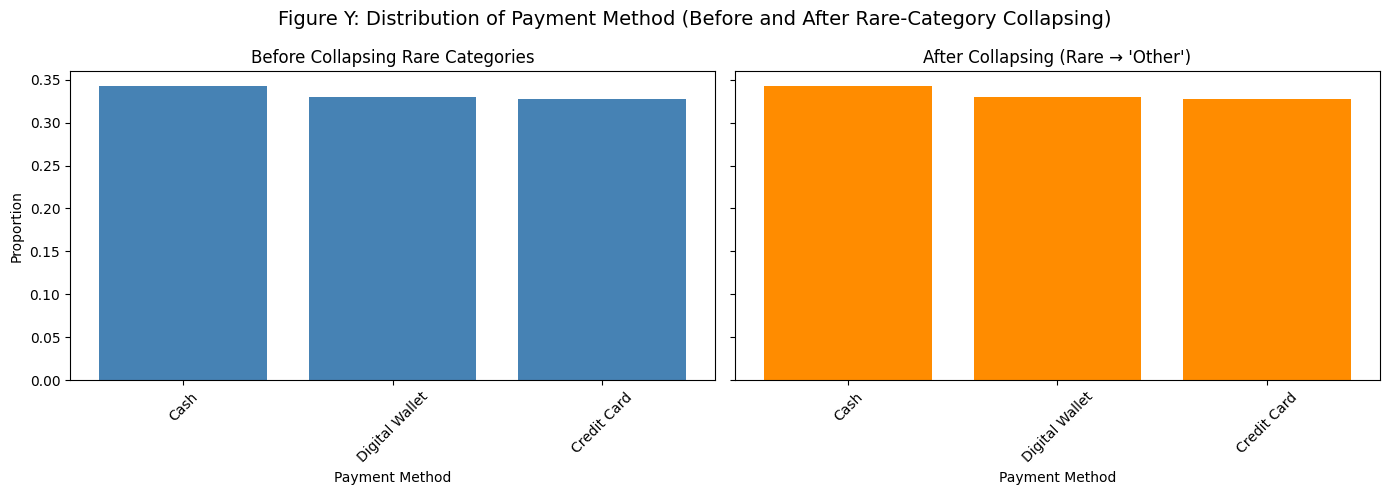

In [9]:
# Payment Method Before vs After Rare-Category Collapsing

if 'Payment Method' in df.columns and 'Payment Method' in df_anon.columns:

    # Before collapsing
    payment_before = df['Payment Method'].value_counts(normalize=True).sort_values(ascending=False)

    # After collapsing
    payment_after = df_anon['Payment Method'].value_counts(normalize=True).sort_values(ascending=False)

    # ide-by-side visualisation
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    # Before plot
    axes[0].bar(payment_before.index, payment_before.values, color='steelblue')
    axes[0].set_title("Before Collapsing Rare Categories", fontsize=12)
    axes[0].set_xlabel("Payment Method")
    axes[0].set_ylabel("Proportion")
    axes[0].tick_params(axis='x', rotation=45)

    # After plot
    axes[1].bar(payment_after.index, payment_after.values, color='darkorange')
    axes[1].set_title("After Collapsing (Rare → 'Other')", fontsize=12)
    axes[1].set_xlabel("Payment Method")
    axes[1].tick_params(axis='x', rotation=45)

    fig.suptitle("Figure Y: Distribution of Payment Method (Before and After Rare-Category Collapsing)", fontsize=14)
    plt.tight_layout()
    plt.show()

else:
    print("Column 'Payment Method' not found in df or df_anon.")



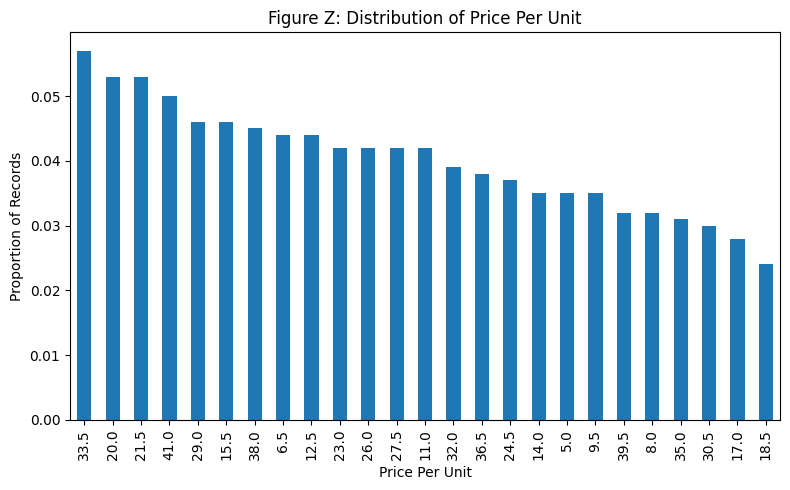

In [10]:
# This plot highlights how one price value dominates the dataset.

if 'Price Per Unit' in df_anon.columns:
    plt.figure(figsize=(8, 5))

    # Convert to categorical (if needed) for plot readability
    price_counts = df_anon['Price Per Unit'].value_counts(normalize=True).round(3)

    price_counts.plot(kind='bar')

    plt.title("Figure Z: Distribution of Price Per Unit")
    plt.xlabel("Price Per Unit")
    plt.ylabel("Proportion of Records")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Price Per Unit' not found in df_anon.")


#4.3 Automated data pipeline

In [11]:
df = df_anon.copy()


In [12]:
# Feature groups
numeric_features = ["Price Per Unit", "Quantity", "Total Spent"]
categorical_features = ["Category", "Item", "Payment Method", "Location"]
date_features = [c for c in df.columns if 'date' in c.lower()]


In [13]:
threshold = df['Total Spent'].quantile(0.75)
df['HighValue'] = (df['Total Spent'] >= threshold).astype(int)
target = "HighValue"


In [14]:
X = df.drop(columns=[target])
y = df[target]

In [15]:
#numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [16]:
#categorical feature pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])


In [17]:
#combined column transformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline, categorical_features)
])

In [18]:
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [20]:
# Fit the pipeline
full_pipeline.fit(X_train, y_train)
print("Pipeline successfully trained on anonymized data.")

Pipeline successfully trained on anonymized data.


# **4.4** Model Redevevelopment & Evaluation

In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**1. logistic Regression**

In [22]:
#Prediction
y_pred_lr = full_pipeline.predict(X_test)
y_proba_lr = full_pipeline.predict_proba(X_test)[:, 1]

In [23]:
# Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_proba_lr)

In [24]:
# printing the performance
print("Logistic Regression Performance:")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")
print(f"AUC      : {lr_auc:.4f}")

Logistic Regression Performance:
Accuracy : 0.9927
Precision: 0.9780
Recall   : 0.9921
F1-score : 0.9850
AUC      : 0.9998


**2. Confusion Matrix Heatmap**

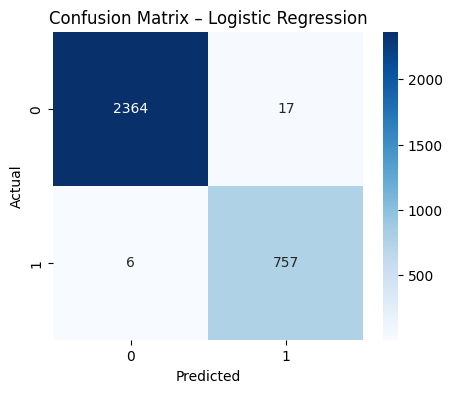

In [25]:
#Compute confusion matrix for logistic regression predictions
cm = confusion_matrix(y_test, y_pred_lr)

#Plot the confusion matrix as a heatmap for easier visual interpretation
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#4.5 Data visualisation & Story telling

In [26]:
from bokeh.io import output_notebook
from bokeh.plotting import figure, show
from bokeh.models import (
    ColumnDataSource,
    HoverTool,
    CDSView,
    BooleanFilter,
    CategoricalColorMapper,
)
from bokeh.transform import dodge, factor_cmap
from bokeh.palettes import Category20

from sklearn.metrics import roc_curve

output_notebook()


In [27]:
#preapring data
df['HighValue_str'] = df['HighValue'].map({0: 'Normal', 1: 'High-Value'})
source = ColumnDataSource(df)

color_mapper = CategoricalColorMapper(factors=['Normal','High-Value'], palette=['#4575b4','#d73027'])

# Bokeh config
p = figure(
    title="EDA: Price Per Unit vs Quantity",
    x_axis_label="Price Per Unit",
    y_axis_label="Quantity",
    height=400,
    tools="pan,wheel_zoom,box_zoom,reset,save"
)

# Scatter plot
p.circle(
    x='Price Per Unit',
    y='Quantity',
    source=source,
    size=8,
    color={'field': 'HighValue_str', 'transform': color_mapper},
    alpha=0.6,
    legend_field='HighValue_str'
)

# Hover tool
hover = HoverTool(tooltips=[
    ("Item", "@Item"),
    ("Category", "@Category"),
    ("Price Per Unit", "@{Price Per Unit}"),
    ("Quantity", "@Quantity"),
    ("Total Spent", "@{Total Spent}")
])
p.add_tools(hover)

# Styling
p.legend.location = "top_right"
p.legend.click_policy = "hide"
p.xgrid.grid_line_color = None
p.ygrid.grid_line_color = None

show(p)


In [28]:

fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

p = figure(title="ROC Curve - Logistic Regression", x_axis_label='False Positive Rate',
           y_axis_label='True Positive Rate', height=400)

p.line(fpr, tpr, line_width=3, color='green', legend_label=f"AUC = {lr_auc:.3f}")
p.line([0,1],[0,1], line_dash='dashed', color='gray')

hover = HoverTool(tooltips=[("FPR", "@x"), ("TPR", "@y")])
p.add_tools(hover)

p.legend.location = "bottom_right"
show(p)


In [29]:


source = ColumnDataSource(data=dict(
    index=list(range(len(y_test))),
    actual=y_test.tolist(),
    predicted=full_pipeline.predict_proba(X_test)[:, 1].tolist()
))

p = figure(title="Predicted vs Actual - Logistic Regression",
           x_axis_label='Index', y_axis_label='Predicted Probability',
           height=400, tools="hover,pan,box_zoom,reset,save",
           tooltips=[("Index", "@index"), ("Actual", "@actual"), ("Predicted Prob", "@predicted")])

p.scatter(x='index', y='predicted', source=source, size=6, color='navy', alpha=0.6) #scatter plot

show(p)


In [30]:


category_summary = df.groupby(['Category','HighValue']).size().reset_index(name='count')
source = ColumnDataSource(category_summary)

# Filter
normal_filter = BooleanFilter([val==0 for val in category_summary['HighValue']])
high_filter   = BooleanFilter([val==1 for val in category_summary['HighValue']])

categories = category_summary['Category'].unique().tolist()
colors = ["#4575b4", "#d73027"]

p = figure(
    x_range=categories,
    height=400,
    title="Transactions by Category",
    toolbar_location="above",
    tools="hover,pan,box_zoom,reset,save",
    tooltips="@Category: @count transactions"
)
#normal
p.vbar(
    x=dodge('Category', -0.15, range=p.x_range),
    top='count',
    width=0.3,
    source=source,
    legend_label="Normal",
    color=colors[0],
    view=CDSView(filter=normal_filter)
)
#high
p.vbar(
    x=dodge('Category', 0.15, range=p.x_range),
    top='count',
    width=0.3,
    source=source,
    legend_label="High-Value",
    color=colors[1],
    view=CDSView(filter=high_filter)
)

p.legend.click_policy = "hide"
p.x_range.range_padding = 0.1
p.xgrid.grid_line_color = None
p.y_range.start = 0

show(p)


In [32]:
from bokeh.models import Label

# Compare Normal vs High-Value transactions
summary = df.groupby('HighValue').agg({
    'Total Spent': 'mean',
    'Quantity': 'mean',
    'Price Per Unit': 'mean'
}).round(1)
#store it in a dictionary type format so its easy to call features

source = ColumnDataSource(dict(
    feature=['Total Spent', 'Quantity', 'Price Per Unit'],
    normal=summary.loc[0].values,
    high=summary.loc[1].values
))
#Bokeh figure configuring
p = figure(
    y_range=['Price Per Unit', 'Quantity', 'Total Spent'][::-1],
    height=380,
    title="High-Value Transactions tend to have a larger Basket Size",
    tools="hover,pan,wheel_zoom,box_zoom,reset,save",
    toolbar_location="right",
    active_scroll="wheel_zoom"
)

p.hbar(y='feature', right='normal', height=0.9, source=source,
       color="#4575b4", legend_label="Normal")

p.hbar(y='feature', right='high', height=0.4, source=source,
       color="#d73027", legend_label="High-Value")

p.add_tools(HoverTool(tooltips=[
    ("Feature", "@feature"),
    ("Normal", "@normal{0.0}"),
    ("High-Value", "@high{0.0}")
]))

p.add_layout(Label(x=100, y=1.7, text="High-value = bigger baskets!",
                   text_font_size="9pt", text_color="black"))

p.legend.location = "top_right"
p.legend.click_policy = "hide"

show(p)

In [33]:


cat_spend = df.groupby(['Category','HighValue'])['Total Spent'].mean().reset_index()
cat_spend['Total Spent'] = cat_spend['Total Spent'].round(1)

source = ColumnDataSource(cat_spend)

# Filters
normal_filter = BooleanFilter([v == 0 for v in cat_spend['HighValue']])
high_filter   = BooleanFilter([v == 1 for v in cat_spend['HighValue']])

categories = cat_spend['Category'].unique().tolist()
colors = ["#4575b4", "#d73027"]

p = figure(
    x_range=categories,
    height=400,
    title="Average Spending per Category (Normal vs High-Value)",
    toolbar_location="above",
    tools="hover,pan,box_zoom,reset,save",
    tooltips=[("Category", "@Category"), ("Avg Spent", "@{Total Spent}")]
)

# Normal bar
p.vbar(
    x=dodge('Category', -0.15, range=p.x_range),
    top='Total Spent',
    width=0.3,
    source=source,
    color=colors[0],
    legend_label="Normal",
    view=CDSView(filter=normal_filter)
)

# High-value bar
p.vbar(
    x=dodge('Category', 0.15, range=p.x_range),
    top='Total Spent',
    width=0.3,
    source=source,
    color=colors[1],
    legend_label="High-Value",
    view=CDSView(filter=high_filter)
)

p.legend.click_policy = "hide"
p.x_range.range_padding = 0.1
p.xgrid.grid_line_color = None
p.y_range.start = 0
show(p)
